
# Reference surface  


In [ ]:

import os
import numpy as np
import pandas as pd
import nibabel as nb  
import matplotlib.pyplot as plt
import seaborn as sns  

import sys 
sys.path.append('.../hippunfold_toolbox')
from hippunfold_toolbox import plotting
import hippunfold_toolbox


In [ ]:
 
hippunfold_dir = '.../hcp-hippunfold' 

subject = '100307' 

surface = nib.load(f'{hippunfold_dir}/sub-{subject}/surf/sub-{subject}\
_hemi-L_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii')


In [13]:

# How is surface made? 

print(surface.darrays[0])


print(surface.darrays[0].data) 


print(surface.darrays[1].data)

# --> The surface has 7262 vertices, each vertex has 3 coordinates (x, y, z)



<GiftiDataArray pointset[7262, 3]>
[[-12.777238  -7.869669 -18.571726]
 [-16.711533 -12.815897 -15.661795]
 [-16.442417 -13.183359 -15.888004]
 ...
 [-25.542807 -20.602192 -14.043811]
 [-25.735106 -21.22707  -13.742723]
 [-25.760897 -21.526768 -13.573153]]
[[ 145  242  240]
 [ 242  305  240]
 [   4  358   29]
 ...
 [4490 4491 4474]
 [4490 4473 4472]
 [4489 4490 4472]]


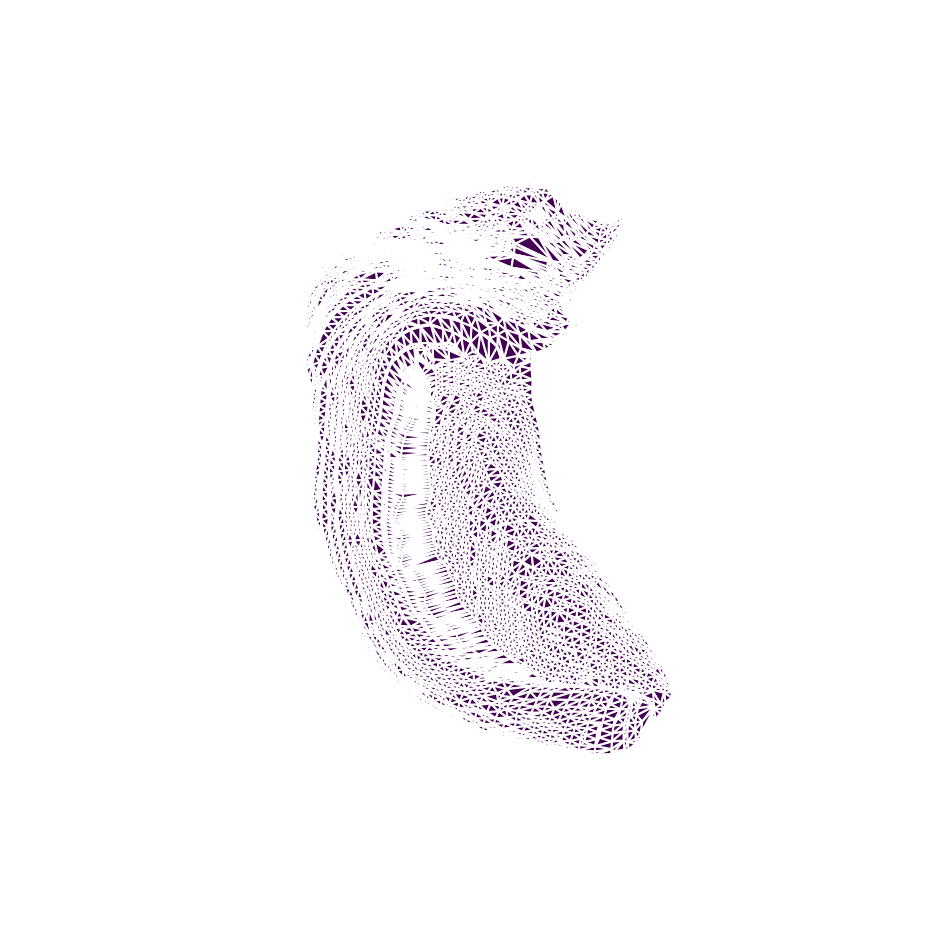

In [ ]:

# this is the surface of one subject

fig,ax = plotting.plot_gifti(surface)


ax.view_init(elev=90, azim=-90)




In [ ]:
 # here we compute the average surface across subjects 

SUBJ_LIST = 'subjects...txt'

with open(SUBJ_LIST, 'r') as f:
    subjects_to_include = ['sub-' + line.strip() for line in f.readlines()]
 


all_vertices = []


for subject in subjects_to_include:
    
    surface_path = f'{hippunfold_dir}/{subject}/surf/{subject}_hemi-L_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii'
    
    surface = nib.load(surface_path)
    vertices = surface.darrays[0].data

    
    all_vertices.append(vertices)

 
all_vertices = np.array(all_vertices)

 
mean_vert = np.mean(all_vertices, axis=0)




In [ ]:
 


# We have the vertices and we miss the triangles in mean_surface_gii.darrays[1] so we take the faces of an example subject
# (since triangles are the same across subjects for a given template)

surface_example = nb.load(os.path.join(hippunfold_dir, 'sub-100307', 'surf', 'sub-100307_hemi-L_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii'))
faces = surface_example.darrays[1].data

vert = nb.gifti.GiftiDataArray(mean_vert, intent='NIFTI_INTENT_POINTSET')
faces = nb.gifti.GiftiDataArray(faces, intent='NIFTI_INTENT_TRIANGLE')

# Create a GIFTI image with vertices and faces
mean_surface = nb.gifti.GiftiImage(darrays=[vert, faces])



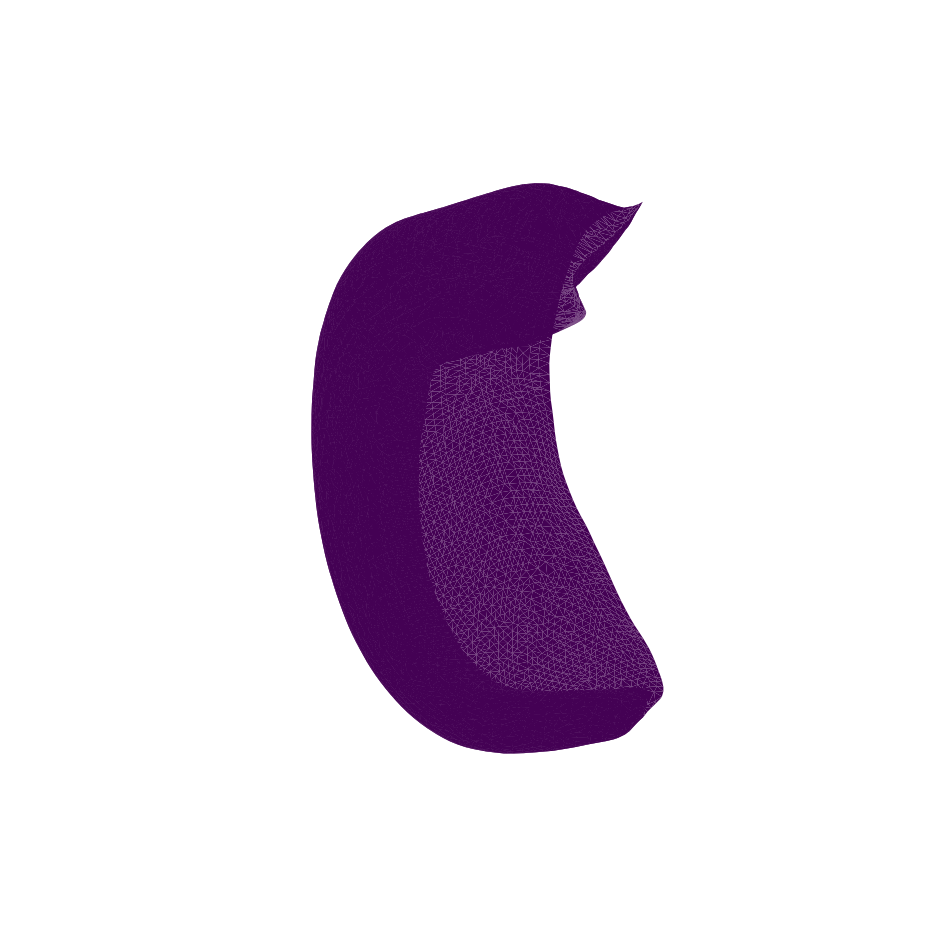

In [ ]:


fig,ax = plotting.plot_gifti(mean_surface)



ax.view_init(elev=90, azim=-90)




# Mean Structure


In [ ]:
 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap
import matplotlib as mpl


In [ ]:
 

hippunfold_dir = '.../hcp-hippunfold'


tmpdir = '.../hcp-t1wt2w-hippunfold'


subject = '100307'


proxy = nb.load(f'{tmpdir}/sub-{subject}_T1wT2w.shape.gii')
 



In [ ]:


vertex_metrics = {
    'thickness': [],
    'surfarea': [],
    'gyrification': [],
    'curvature': [],
    't1wt2w': []
}

tmpdir = '.../hcp-t1wt2w-hippunfold'



In [ ]:


for subjID in subjects_to_include:
    subj_surf_dir = os.path.join(hippunfold_dir, subjID, 'surf')

    
    metric_files = {
        'thickness': f"{subjID}_hemi-L_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii",
        'surfarea': f"{subjID}_hemi-L_space-T1w_den-0p5mm_label-hipp_surfarea.shape.gii",
        'gyrification': f"{subjID}_hemi-L_space-T1w_den-0p5mm_label-hipp_gyrification.shape.gii",
        'curvature': f"{subjID}_hemi-L_space-T1w_den-0p5mm_label-hipp_curvature.shape.gii",
    }

    
 
    for metric, fname in metric_files.items():
        fpath = os.path.join(subj_surf_dir, fname)
        data = nb.load(fpath).agg_data()  # shape: (num_vertices,)
        vertex_metrics[metric].append(data)  

    
  
    t1t2_file = os.path.join(tmpdir, f"{subjID}_T1wT2w.shape.gii")
    T1T2 = nb.load(t1t2_file).agg_data()
    vertex_metrics['t1wt2w'].append(T1T2)

 
for metric in vertex_metrics:
    vertex_metrics[metric] = np.array(vertex_metrics[metric])  
    # shape: (num_subjects, num_vertices)
 




In [ ]:
# Compute vertex-wise mean across subjects
 
mean_thickness = np.mean(vertex_metrics['thickness'], axis=0)  # shape: (7262,)
mean_surfarea = np.mean(vertex_metrics['surfarea'], axis=0)
mean_gyrification = np.mean(vertex_metrics['gyrification'], axis=0)
mean_curvature = np.mean(vertex_metrics['curvature'], axis=0)
mean_t1wt2w = np.mean(vertex_metrics['t1wt2w'], axis=0)
  

In [ ]:

def plot_mean_structure(mean_surface, mean_structure, min, max):
    faces = mean_surface.darrays[1].data  
    face_values = mean_structure[faces].mean(axis=1)

    base_cmap = mpl.colormaps['magma']

    vals = base_cmap(np.linspace(0, 1, 256)) 
    my_custom_cmap = ListedColormap(vals) 

    fig, ax = plotting.plot_gifti(mean_surface, 'fill', cmap=False)

    mappable = ax.collections[0]

    mappable.set_array(face_values)  

    mappable.set_edgecolor('none') 

    mappable.set_cmap(my_custom_cmap)
    norm = Normalize(vmin=min, vmax=max)
    mappable.set_norm(norm) 

    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6) 
    
    return fig, ax